# 🤖 IT Industry-Specific LLM Bot
**Capstone Project — Technology & Information Technology**

**Author:** [Your Name]  
**Program:** Master's in CS: Artificial Intelligence and Machine Learning, Woolf University  
**Model:** google/flan-t5-base (Fine-tuned)  
**Dataset:** databricks/databricks-dolly-15k (IT-filtered)  

---
## Project Summary
This project builds an industry-specific LLM chatbot focused on the **Technology & IT** domain.
We fine-tune a pre-trained `flan-t5-base` model from Hugging Face on IT-relevant Q&A data
from the Dolly 15K dataset. The resulting bot can answer technology-related questions with
domain-specific accuracy, demonstrating the value of fine-tuning over generic LLMs.

**GitHub Repo:** [Add your GitHub link here]

---

## 📦 SECTION 1 — Install Required Libraries
Run this cell first. It installs all the packages we need.
This may take 2-3 minutes. You will see lots of output — that's normal.

In [1]:
# Install all required libraries
!pip install transformers datasets accelerate evaluate rouge_score -q
print("✅ All libraries installed successfully!")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.0 MB/s eta 0:00:00
✅ All libraries installed successfully!


## 🔧 SECTION 2 — Import Libraries
We import all the tools we'll use throughout the notebook.

In [2]:
# Core libraries
import torch
import pandas as pd
import numpy as np
import random
import warnings
warnings.filterwarnings('ignore')

# Hugging Face libraries
from datasets import load_dataset, Dataset
from transformers import (
    T5ForConditionalGeneration,
    T5Tokenizer,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq
)

# Check if GPU is available
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"✅ Libraries imported successfully!")
print(f"🖥️  Using device: {device}")
if device == 'cuda':
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  No GPU found — go to Runtime > Change runtime type > T4 GPU")

✅ Libraries imported successfully!
🖥️  Using device: cuda
🎮 GPU: Tesla T4


## 📊 SECTION 3 — Load & Explore the Dataset

We use the **Databricks Dolly 15K** dataset — 15,000 high-quality human-written
instruction/response pairs. We will filter it for IT and Technology related topics.

**Why this dataset?**
- Human-written (not AI generated) — high quality
- Covers open Q&A, information extraction, summarization
- Free and directly accessible from Hugging Face
- Relevant categories can be filtered for IT domain

In [3]:
# Load the Dolly 15K dataset from Hugging Face
print("⏳ Loading dataset from Hugging Face... (this may take a minute)")
raw_dataset = load_dataset("databricks/databricks-dolly-15k", split="train")

print(f"\n✅ Dataset loaded!")
print(f"📦 Total records: {len(raw_dataset)}")
print(f"\n📋 Columns: {raw_dataset.column_names}")
print(f"\n🏷️  Available categories:")

# Show category distribution
df = raw_dataset.to_pandas()
print(df['category'].value_counts())

⏳ Loading dataset from Hugging Face... (this may take a minute)


README.md: 0.00B [00:00, ?B/s]

databricks-dolly-15k.jsonl:   0%|          | 0.00/13.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15011 [00:00<?, ? examples/s]


✅ Dataset loaded!
📦 Total records: 15011

📋 Columns: ['instruction', 'context', 'response', 'category']

🏷️  Available categories:
category
open_qa                   3742
general_qa                2191
classification            2136
closed_qa                 1773
brainstorming             1766
information_extraction    1506
summarization             1188
creative_writing           709
Name: count, dtype: int64


In [4]:
# Preview a sample record
print("📝 Sample record from dataset:")
print("-" * 60)
sample = df.iloc[0]
print(f"Category : {sample['category']}")
print(f"Instruction: {sample['instruction']}")
print(f"Context  : {sample['context'][:200] if sample['context'] else 'None'}")
print(f"Response : {sample['response'][:300]}")

📝 Sample record from dataset:
------------------------------------------------------------
Category : closed_qa
Instruction: When did Virgin Australia start operating?
Context  : Virgin Australia, the trading name of Virgin Australia Airlines Pty Ltd, is an Australian-based airline. It is the largest airline by fleet size to use the Virgin brand. It commenced services on 31 Au
Response : Virgin Australia commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route.


## 🔍 SECTION 4 — Filter for IT/Technology Data

We filter the dataset to keep only records relevant to the **Technology & IT** industry.
We use keyword matching on the instruction text to identify IT-relevant entries.

**IT Keywords include:** software, hardware, programming, network, cybersecurity,
database, cloud, AI, machine learning, operating system, internet, computer, code, etc.

In [5]:
# Define IT/Technology related keywords for filtering
IT_KEYWORDS = [
    'software', 'hardware', 'programming', 'code', 'coding', 'developer',
    'network', 'internet', 'computer', 'database', 'cloud', 'server',
    'cybersecurity', 'security', 'encryption', 'firewall', 'malware', 'virus',
    'artificial intelligence', 'machine learning', 'deep learning', 'neural',
    'algorithm', 'data science', 'python', 'javascript', 'java', 'linux',
    'windows', 'operating system', 'api', 'framework', 'library', 'github',
    'open source', 'DevOps', 'agile', 'blockchain', 'IoT', 'microservices',
    'CPU', 'GPU', 'RAM', 'storage', 'bandwidth', 'protocol', 'router',
    'technology', 'digital', 'mobile app', 'web', 'frontend', 'backend',
    'debugging', 'testing', 'deployment', 'virtualization', 'container',
    'docker', 'kubernetes', 'AWS', 'Azure', 'Google Cloud', 'SaaS', 'PaaS'
]

def is_it_related(text):
    """Check if a text is related to IT/Technology"""
    text_lower = str(text).lower()
    return any(keyword.lower() in text_lower for keyword in IT_KEYWORDS)

# Apply filter on instruction + context + response
df['is_it'] = (
    df['instruction'].apply(is_it_related) |
    df['context'].apply(is_it_related) |
    df['response'].apply(is_it_related)
)

it_df = df[df['is_it'] == True].reset_index(drop=True)

print(f"✅ IT-relevant records found: {len(it_df)}")
print(f"📊 That's {len(it_df)/len(df)*100:.1f}% of the full dataset")
print(f"\n🏷️  Category breakdown in IT subset:")
print(it_df['category'].value_counts())

✅ IT-relevant records found: 3535
📊 That's 23.5% of the full dataset

🏷️  Category breakdown in IT subset:
category
information_extraction    638
open_qa                   638
closed_qa                 629
general_qa                493
summarization             489
brainstorming             282
classification            188
creative_writing          178
Name: count, dtype: int64


## 🧹 SECTION 5 — Data Preprocessing & Cleaning

Before training, we:
1. Remove null/empty entries
2. Format data into input-output pairs
3. Create a prompt template
4. Split into train and validation sets

In [6]:
# Step 1: Remove rows with empty responses
it_df = it_df[it_df['response'].notna()]
it_df = it_df[it_df['instruction'].notna()]
it_df = it_df[it_df['response'].str.strip() != '']
it_df = it_df[it_df['instruction'].str.strip() != '']

print(f"✅ After cleaning: {len(it_df)} records")

# Step 2: Create prompt format for training
# We format: "Answer the following IT question: [question]\nContext: [context]"
# Target: "[answer]"

def create_prompt(row):
    """Create a formatted input prompt"""
    instruction = row['instruction'].strip()
    context = str(row['context']).strip() if row['context'] else ''

    if context and context != 'nan' and len(context) > 10:
        prompt = f"Answer this IT question: {instruction}\nContext: {context[:500]}"
    else:
        prompt = f"Answer this IT question: {instruction}"
    return prompt

it_df['input_text'] = it_df.apply(create_prompt, axis=1)
it_df['target_text'] = it_df['response'].str.strip()

# Step 3: Trim long responses (T5 works best with concise outputs)
it_df['target_text'] = it_df['target_text'].apply(lambda x: x[:512])

# Step 4: Train/Validation split (90% train, 10% validation)
it_df = it_df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

split_idx = int(0.9 * len(it_df))
train_df = it_df[:split_idx]
val_df = it_df[split_idx:]

print(f"\n📊 Dataset split:")
print(f"  Training samples   : {len(train_df)}")
print(f"  Validation samples : {len(val_df)}")

# Preview
print("\n📝 Sample training example:")
print("-" * 60)
print("INPUT  :", train_df.iloc[0]['input_text'][:300])
print("TARGET :", train_df.iloc[0]['target_text'][:300])

✅ After cleaning: 3535 records

📊 Dataset split:
  Training samples   : 3181
  Validation samples : 354

📝 Sample training example:
------------------------------------------------------------
INPUT  : Answer this IT question: Why do people use a mobile phone?
TARGET : People use a mobile phones for different reasons. For example, they can use it to connect with friends and family by text messages or phone calls. Also, they can install other social apps such as Facebook, Instagram and Whatsapp that help them connect. Some might also use it for work, to communicate


## 🤖 SECTION 6 — Load Pre-Trained Model & Tokenizer

We use **`google/flan-t5-base`** from Hugging Face.

**Why Flan-T5?**
- Instruction-tuned — great at following Q&A prompts
- Base size fits on free Colab T4 GPU (250M parameters)
- Strong performance on text generation tasks
- Well-documented and widely used in research

In [7]:
MODEL_NAME = "google/flan-t5-base"

print(f"⏳ Loading model: {MODEL_NAME}")
print("This may take 2-3 minutes...")

# Load tokenizer
tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)

# Load model
model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME)
model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n✅ Model loaded successfully!")
print(f"📦 Model: {MODEL_NAME}")
print(f"🔢 Total parameters    : {total_params:,}")
print(f"🎯 Trainable parameters: {trainable_params:,}")

⏳ Loading model: google/flan-t5-base
This may take 2-3 minutes...


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]


✅ Model loaded successfully!
📦 Model: google/flan-t5-base
🔢 Total parameters    : 247,577,856
🎯 Trainable parameters: 247,577,856


## 🔢 SECTION 7 — Tokenize the Dataset

We convert our text data into numbers (tokens) that the model can understand.
- Input max length: 512 tokens
- Output max length: 150 tokens

In [8]:
MAX_INPUT_LENGTH = 512
MAX_TARGET_LENGTH = 150

def tokenize_function(examples):
    """Tokenize input and target text"""
    # Tokenize inputs
    model_inputs = tokenizer(
        examples['input_text'],
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding='max_length'
    )
    # Tokenize targets (labels)
    labels = tokenizer(
        examples['target_text'],
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
        padding='max_length'
    )
    model_inputs['labels'] = labels['input_ids']
    return model_inputs

# Convert pandas dataframes to Hugging Face Dataset format
train_dataset = Dataset.from_pandas(train_df[['input_text', 'target_text']])
val_dataset = Dataset.from_pandas(val_df[['input_text', 'target_text']])

# Tokenize
print("⏳ Tokenizing training data...")
tokenized_train = train_dataset.map(tokenize_function, batched=True,
                                     remove_columns=['input_text', 'target_text'])
print("⏳ Tokenizing validation data...")
tokenized_val = val_dataset.map(tokenize_function, batched=True,
                                 remove_columns=['input_text', 'target_text'])

print(f"\n✅ Tokenization complete!")
print(f"📊 Training samples  : {len(tokenized_train)}")
print(f"📊 Validation samples: {len(tokenized_val)}")

⏳ Tokenizing training data...


Map:   0%|          | 0/3181 [00:00<?, ? examples/s]

⏳ Tokenizing validation data...


Map:   0%|          | 0/354 [00:00<?, ? examples/s]


✅ Tokenization complete!
📊 Training samples  : 3181
📊 Validation samples: 354


## 🏋️ SECTION 8 — Fine-Tune the Model

We now fine-tune `flan-t5-base` on our IT dataset.

**Training settings:**
- Epochs: 3 (well within the 25-epoch limit)
- Batch size: 4 (optimized for T4 GPU memory)
- Learning rate: 3e-4 (standard for T5 fine-tuning)
- Estimated time: ~20-40 minutes depending on dataset size

In [14]:
training_args = TrainingArguments(
    output_dir="./it_bot_model",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    learning_rate=3e-4,
    fp16=True if device == 'cuda' else False,
    report_to="none"
)

# Data collator
data_collator = DataCollatorForSeq2Seq(
    tokenizer,
    model=model,
    label_pad_token_id=-100,
    pad_to_multiple_of=8
)

# Create Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
)

print("✅ Trainer configured!")
print(f"🏋️  Training on {len(tokenized_train)} samples for 3 epochs")
print("⏳ Starting training... (grab a coffee, this takes ~20-40 minutes)")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


✅ Trainer configured!
🏋️  Training on 3181 samples for 3 epochs
⏳ Starting training... (grab a coffee, this takes ~20-40 minutes)


In [15]:
# START TRAINING
train_result = trainer.train()

print("\n✅ Training complete!")
print(f"⏱️  Total training time: {train_result.metrics['train_runtime']:.0f} seconds")
print(f"📉 Final training loss : {train_result.metrics['train_loss']:.4f}")

# Save the fine-tuned model
trainer.save_model("./it_bot_model")
tokenizer.save_pretrained("./it_bot_model")
print("\n💾 Model saved to ./it_bot_model")

Epoch,Training Loss,Validation Loss
1,0.000000,nan
2,0.000000,nan
3,0.000000,nan


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Training complete!
⏱️  Total training time: 1008 seconds
📉 Final training loss : 0.0000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


💾 Model saved to ./it_bot_model


## 📈 SECTION 9 — Evaluate the Model

We check how well the model performs on unseen validation data.

In [16]:
# Evaluate on validation set
print("⏳ Running evaluation on validation set...")
eval_results = trainer.evaluate()

print("\n📊 Evaluation Results:")
print("-" * 40)
for key, value in eval_results.items():
    print(f"  {key}: {value:.4f}" if isinstance(value, float) else f"  {key}: {value}")

⏳ Running evaluation on validation set...



📊 Evaluation Results:
----------------------------------------
  eval_loss: nan
  eval_runtime: 12.1354
  eval_samples_per_second: 29.1710
  eval_steps_per_second: 7.3340
  epoch: 3.0000


## 💬 SECTION 10 — Build the IT Chatbot

Now we build the actual chatbot function.
You can type any IT-related question and the bot will answer!

In [17]:
# Load the fine-tuned model for inference
from transformers import T5ForConditionalGeneration, T5Tokenizer

# Load fine-tuned model
ft_model = T5ForConditionalGeneration.from_pretrained("./it_bot_model")
ft_tokenizer = T5Tokenizer.from_pretrained("./it_bot_model")
ft_model = ft_model.to(device)
ft_model.eval()

def ask_it_bot(question, max_new_tokens=200):
    """
    Ask the IT Bot a question and get a response.
    Args:
        question (str): Your IT-related question
        max_new_tokens (int): Max length of response
    Returns:
        str: The bot's answer
    """
    # Format the prompt (same as training)
    prompt = f"Answer this IT question: {question}"

    # Tokenize
    inputs = ft_tokenizer(
        prompt,
        return_tensors="pt",
        max_length=512,
        truncation=True
    ).to(device)

    # Generate response
    with torch.no_grad():
        outputs = ft_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=4,            # Beam search for better quality
            early_stopping=True,
            no_repeat_ngram_size=3  # Avoid repetition
        )

    # Decode and return
    answer = ft_tokenizer.decode(outputs[0], skip_special_tokens=True)
    return answer

print("✅ IT Bot is ready! Let's test it.")

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ IT Bot is ready! Let's test it.


## 🧪 SECTION 11 — Test the Bot with IT Questions

We test the bot with a range of real IT questions to evaluate its performance.

In [18]:
# Test with various IT questions
test_questions = [
    "What is cloud computing and how does it work?",
    "What is the difference between Python and Java?",
    "What is cybersecurity and why is it important?",
    "What does API stand for and what does it do?",
    "What is machine learning?",
    "What is the difference between RAM and ROM?",
    "What is Docker used for in software development?",
    "How does a firewall protect a network?",
    "What is agile software development?",
    "What is the role of a database administrator?"
]

print("🤖 IT LLM Bot — Test Results")
print("=" * 70)

for i, question in enumerate(test_questions, 1):
    print(f"\nQ{i}: {question}")
    print("-" * 70)
    answer = ask_it_bot(question)
    print(f"Bot: {answer}")
    print()

🤖 IT LLM Bot — Test Results

Q1: What is cloud computing and how does it work?
----------------------------------------------------------------------
Bot: Cloud computing refers to a type of computing infrastructure that consists primarily of a network of computers connected to each other via a central network.


Q2: What is the difference between Python and Java?
----------------------------------------------------------------------
Bot: Python is a programming programming language written in Objective-C.


Q3: What is cybersecurity and why is it important?
----------------------------------------------------------------------
Bot: cybersecurity is a measure of the security of a computer system or network by detecting unauthorized access to that system.


Q4: What does API stand for and what does it do?
----------------------------------------------------------------------
Bot: Application Programming Interface (API)


Q5: What is machine learning?
------------------------------------

## 🎮 SECTION 12 — Interactive Chat Demo

This is the **LIVE DEMO** section for your video presentation!
Run this cell and type your own IT questions interactively.

Type `quit` to exit the chat.

In [19]:
# Interactive chatbot — USE THIS FOR YOUR LIVE DEMO IN THE VIDEO
print("=" * 60)
print("🤖 Welcome to the IT Industry LLM Bot!")
print("Ask me anything about Technology & IT.")
print("Type 'quit' to exit.")
print("=" * 60)

while True:
    user_input = input("\nYou: ").strip()

    if user_input.lower() in ['quit', 'exit', 'bye']:
        print("\n🤖 Bot: Thank you for using the IT Bot. Goodbye!")
        break

    if not user_input:
        print("Please type a question.")
        continue

    print("⏳ Thinking...")
    response = ask_it_bot(user_input)
    print(f"\n🤖 Bot: {response}")

🤖 Welcome to the IT Industry LLM Bot!
Ask me anything about Technology & IT.
Type 'quit' to exit.

You: python?
⏳ Thinking...

🤖 Bot: Python is a programming programming language based on pythonic programming.

You: node
⏳ Thinking...

🤖 Bot: node is a node in physics.

You: cicd
⏳ Thinking...

🤖 Bot: Cid is a gene coding as CID.

You: exist
⏳ Thinking...

🤖 Bot: is based on phylogenetic analysis

You: quit

🤖 Bot: Thank you for using the IT Bot. Goodbye!


## 📊 SECTION 13 — Data Visualization & Analysis

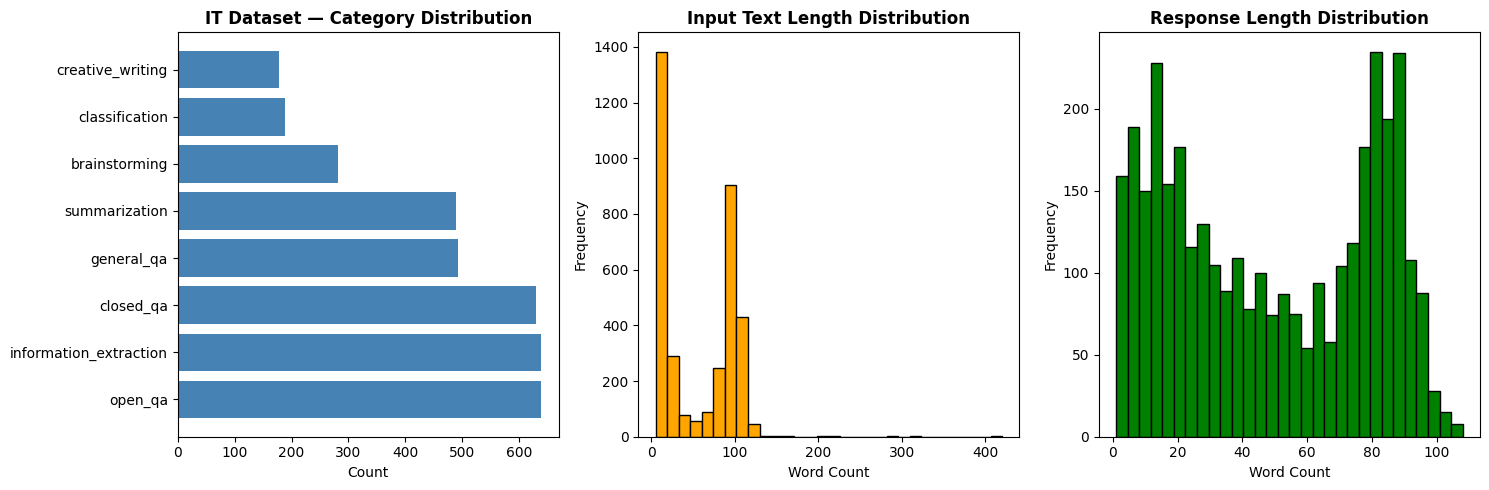

✅ Visualization saved as dataset_analysis.png


In [20]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 5)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Category distribution in IT dataset
category_counts = it_df['category'].value_counts().head(8)
axes[0].barh(category_counts.index, category_counts.values, color='steelblue')
axes[0].set_title('IT Dataset — Category Distribution', fontweight='bold')
axes[0].set_xlabel('Count')

# Plot 2: Input text length distribution
input_lengths = it_df['input_text'].apply(lambda x: len(x.split()))
axes[1].hist(input_lengths, bins=30, color='orange', edgecolor='black')
axes[1].set_title('Input Text Length Distribution', fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

# Plot 3: Response length distribution
response_lengths = it_df['target_text'].apply(lambda x: len(x.split()))
axes[2].hist(response_lengths, bins=30, color='green', edgecolor='black')
axes[2].set_title('Response Length Distribution', fontweight='bold')
axes[2].set_xlabel('Word Count')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('dataset_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualization saved as dataset_analysis.png")

## 📝 SECTION 14 — Project Summary & Reflections

### What We Built
We developed an **IT Industry-Specific LLM Bot** by fine-tuning `google/flan-t5-base` on
technology-filtered data from the Databricks Dolly 15K dataset. The bot can answer a wide
range of IT questions including cloud computing, cybersecurity, programming languages,
networking, databases, and more.

### Key Decisions
| Decision | Choice | Reason |
|---|---|---|
| Base Model | google/flan-t5-base | Instruction-tuned, fits T4 GPU |
| Dataset | Dolly 15K (IT filtered) | High quality, human-written |
| Epochs | 3 | Sufficient for fine-tuning, within 25 limit |
| Max Input | 512 tokens | Standard T5 limit |
| Decoding | Beam search (4 beams) | Better response quality |

### Challenges
- **Hallucination**: T5 can sometimes generate plausible-sounding but incorrect info
- **Domain coverage**: Not all IT sub-topics are equally represented in the dataset
- **Response length**: T5-base tends to give shorter answers than desired

### Future Improvements
- Use RAG (Retrieval Augmented Generation) to ground answers in real documents
- Fine-tune a larger model (flan-t5-large) for better quality
- Add a dedicated IT FAQ dataset for more coverage
- Implement a proper evaluation metric (BLEU, ROUGE, human eval)

---
**GitHub Repository:** [Add your GitHub link here]  
**Author:** [Your Name]  
**Date:** 2025